In [8]:
import stim
import pymatching
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def surface_code_circuit(p, d): # physical error rate, distance
  return stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    rounds=d,
    distance=d,
    after_clifford_depolarization=p,
    after_reset_flip_probability=p,
    before_measure_flip_probability=p,
    before_round_data_depolarization=p)

def count_logical_errors(circuit: stim.Circuit, num_shots: int) -> int:
  # Sample the circuit.
  sampler = circuit.compile_detector_sampler()
  detection_events, observable_flips = sampler.sample(num_shots, separate_observables=True)

  # Configure a decoder using the circuit.
  detector_error_model = circuit.detector_error_model(decompose_errors=True)
  matcher = pymatching.Matching.from_detector_error_model(detector_error_model)

  # Run the decoder.
  predictions = matcher.decode_batch(detection_events)

  # basically compare predictions with observable_flips (what we should have measured)

  # Count the mistakes.
  num_errors = 0
  for shot in range(num_shots):
    actual_for_shot = observable_flips[shot]
    predicted_for_shot = predictions[shot]
    if not np.array_equal(actual_for_shot, predicted_for_shot):
        num_errors += 1
  return num_errors

def ler_mwpm(p, d): # logical error rate, minimum weight perfect matching
  num_shots = 100000
  circuit = surface_code_circuit(p, d)
  num_errors = count_logical_errors(circuit, num_shots) 

  return num_errors / num_shots

def plot_mwpm(): 
  num_shots = 100000
  for d in [3, 5, 7]:
    xs = []
    ys = []
    for noise in np.linspace(0.001, 0.008, 8):
      ler = ler_mwpm(noise, d)
      xs.append(noise)
      ys.append(ler)
    plt.plot(xs, ys, 'o-', label="d=" + str(d))
  plt.loglog()
  plt.xlabel("physical error rate")
  plt.ylabel("logical error rate per shot")
  plt.legend()
  plt.show()

after_clifford: after every operation e.g. H gate, you will apply X, Y, Z with probability p/3 each <br/>
after_reset_flip: after you do a reset (you think you're resetted to 0 but reset to 1 with probability p) <br/>
before_measure_flip: you should measuring a 0 but with p you're measuring a 1 <br/>
before_round_data_depolarization: we apply the same general error - errors no operation (interaction with the environment - decohere) - idling error

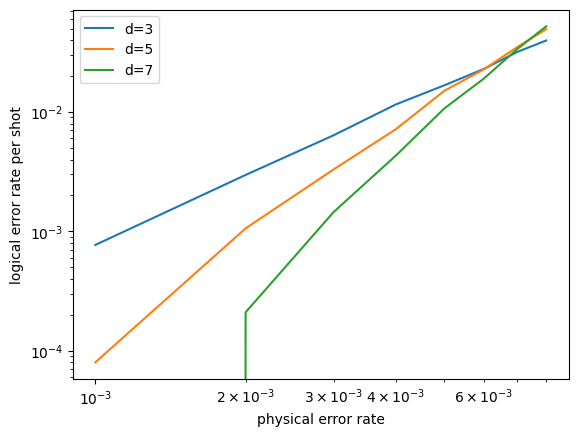

In [11]:
plot_mwpm()